In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dtwpair import SlidingWindowDtwPair
from dtwpair import SchibaSlidingWindowDtwPair
import numpy as np
import matplotlib.pyplot as plt
from dtwpair.utils.dtw_distance import AbsoluteDtwDistance, SquaredDtwDistance
from dtwpair.utils.timer import Timer

import yfinance as yf

In [3]:
# Download S&P500 OHLC data
stock_price = yf.download(['^GSPC', '^IXIC'], start='2000-01-01', end='2025-01-01')['Close']
stock_price = np.log(stock_price)
stock_price = (stock_price - stock_price.rolling(window=365).mean()) / stock_price.rolling(window=365).std()
stock_price = stock_price.dropna()
stock_price

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  2 of 2 completed


Ticker,^GSPC,^IXIC
Date,,
2001-06-13,-1.334244,-1.409667
2001-06-14,-1.561667,-1.529771
2001-06-15,-1.611651,-1.546273
2001-06-18,-1.665562,-1.604134
2001-06-19,-1.608964,-1.586369
...,...,...
2024-12-24,1.603242,1.842212
2024-12-26,1.589149,1.824037
2024-12-27,1.476750,1.688976


In [4]:
x = stock_price['^GSPC'].values
y = stock_price['^IXIC'].values

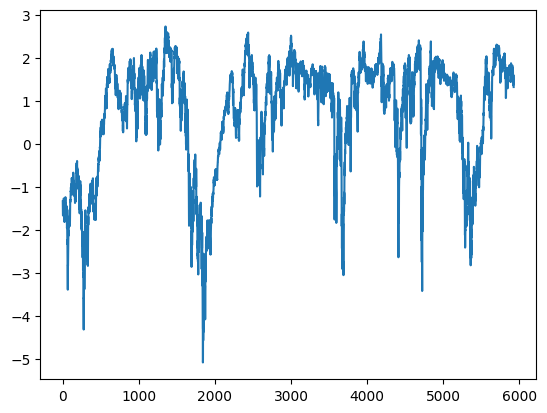

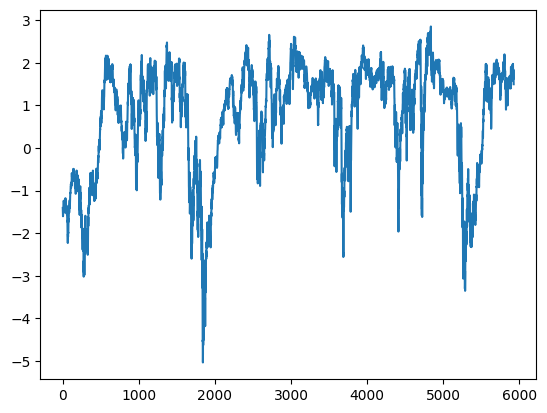

In [5]:
plt.plot(x)
plt.show()
plt.plot(y)
plt.show()

In [ ]:
with Timer():
    dtwp = SlidingWindowDtwPair(dtw_distance=SquaredDtwDistance())
    pairs, min_dtw = dtwp.subsequence_neapairst_neighbour(x, y, 30, 40)
pairs, min_dtw

Computing max_dtw
Elapsed time: 2.99 seconds
Elapsed process time: 3.00 seconds
Computing min_dtw
Elapsed time: 4.61 seconds
Elapsed process time: 4.60 seconds
Computing dtw
Pruned 32236279 out of 34703856 pairs
Elapsed time: 5.60 seconds
Elapsed process time: 5.60 seconds
Elapsed time: 13.86 seconds
Elapsed process time: 13.86 seconds


(array([[2191, 2181]], dtype=int32), array([0.13837414]))

In [ ]:
with Timer():
    dtwp = SchibaSlidingWindowDtwPair(dtw_distance=SquaredDtwDistance(),
                                      window_size=0.5)
    pairs, min_dtw = dtwp.subsequence_neapairst_neighbour(x, y, 30, 40)
pairs, min_dtw

Computing max_dtw
Elapsed time: 2.93 seconds
Elapsed process time: 2.94 seconds
Computing min_dtw
Elapsed time: 20.48 seconds
Elapsed process time: 20.52 seconds
Computing dtw
Pruned 33610866 out of 34703856 pairs
Elapsed time: 6.55 seconds
Elapsed process time: 6.56 seconds
Elapsed time: 30.47 seconds
Elapsed process time: 30.52 seconds


(array([[2191, 2181]], dtype=int32), array([0.13837414]))